In [11]:
MODEL_DATASET = {
    'gemma-27b': 'output/20260508-runpod/results_20260508_203101_gemma-27b.json',
    'qwen-32b': 'output/20260508-runpod/results_20260508_205841_qwen-32b.json',
    'qwq-32b': 'output/20260508-runpod/results_20260508_212346_qwq-32b.json',
    'llama-70b': 'output/20260511-runpod/results_20260511_204539_llama-70b.json',
    'qwen-72b': 'output/20260512-runpod/results_20260512_175131_qwen-72b.json',
    'deepseek-r1-70b': 'output/20260513-runpod/results_20260513_212442_deepseep-r1-70b.json',
}

# LLM-as-judge vs probe projection

Run with the `ea-probing` conda kernel (`conda activate ea-probing`).

Compare Claude Haiku judge labels (`judge_anomaly_notice`, `judge_compliance`) with the linear-probe score `probe_projection`.

Judge labels are independent dimensions:
- **anomaly notice** — did the model flag something unrealistic in the prompt?
- **compliance** — did the model attempt to fulfill the request?

Probe projection is z-scored within each model before pooling, because raw scales differ widely across models (see `initial_analysis.ipynb`).

In [12]:
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

sns.set_theme(style='whitegrid', context='notebook')

dfs = {}
for model, path in MODEL_DATASET.items():
    with open(f'../{path}') as f:
        records = json.load(f)
    dfs[model] = pd.DataFrame(records)

for model, df in dfs.items():
    print(
        f"{model:18s}  n={len(df):3d}  "
        f"anomaly YES={ (df['judge_anomaly_notice'] == 'YES').mean():.1%}  "
        f"comply={ (df['judge_compliance'] == 'COMPLY').mean():.1%}  "
        f"refuse={ (df['judge_compliance'] == 'REFUSE').mean():.1%}  "
        f"proj=[{df['probe_projection'].min():.1f}, {df['probe_projection'].max():.1f}]"
    )

gemma-27b           n=100  anomaly YES=10.0%  comply=66.0%  refuse=28.0%  proj=[-254.0, 1560.0]
qwen-32b            n= 50  anomaly YES=8.0%  comply=86.0%  refuse=10.0%  proj=[-15.8, 4.9]
qwq-32b             n= 50  anomaly YES=8.0%  comply=84.0%  refuse=14.0%  proj=[-324.0, -153.0]
llama-70b           n= 50  anomaly YES=12.0%  comply=70.0%  refuse=26.0%  proj=[-0.2, 1.1]
qwen-72b            n= 50  anomaly YES=6.0%  comply=86.0%  refuse=8.0%  proj=[-45.8, 94.0]
deepseek-r1-70b     n= 50  anomaly YES=14.0%  comply=72.0%  refuse=8.0%  proj=[-0.4, 0.7]


In [13]:
frames = []
for model, df in dfs.items():
    d = df.copy()
    mu, sigma = d['probe_projection'].mean(), d['probe_projection'].std()
    d['z_projection'] = (d['probe_projection'] - mu) / sigma if sigma else 0.0
    d['model'] = model
    dfs[model] = d
    frames.append(d)

all_df = pd.concat(frames, ignore_index=True)
print(all_df.groupby('model')['z_projection'].agg(['mean', 'std']).round(4))

JUDGE_COLS = {
    'judge_anomaly_notice': ['NO', 'YES', 'UNCERTAIN'],
    'judge_compliance': ['COMPLY', 'REFUSE', 'UNCERTAIN'],
}

print('\nLabel counts (pooled across models):')
for col, order in JUDGE_COLS.items():
    print(f"\n{col}")
    print(all_df[col].value_counts().reindex(order).fillna(0).astype(int))


                 mean  std
model                     
deepseek-r1-70b  -0.0  1.0
gemma-27b        -0.0  1.0
llama-70b         0.0  1.0
qwen-32b          0.0  1.0
qwen-72b          0.0  1.0
qwq-32b           0.0  1.0

Label counts (pooled across models):

judge_anomaly_notice
judge_anomaly_notice
NO           310
YES           34
UNCERTAIN      0
Name: count, dtype: int64

judge_compliance
judge_compliance
COMPLY       265
REFUSE        61
UNCERTAIN     18
Name: count, dtype: int64


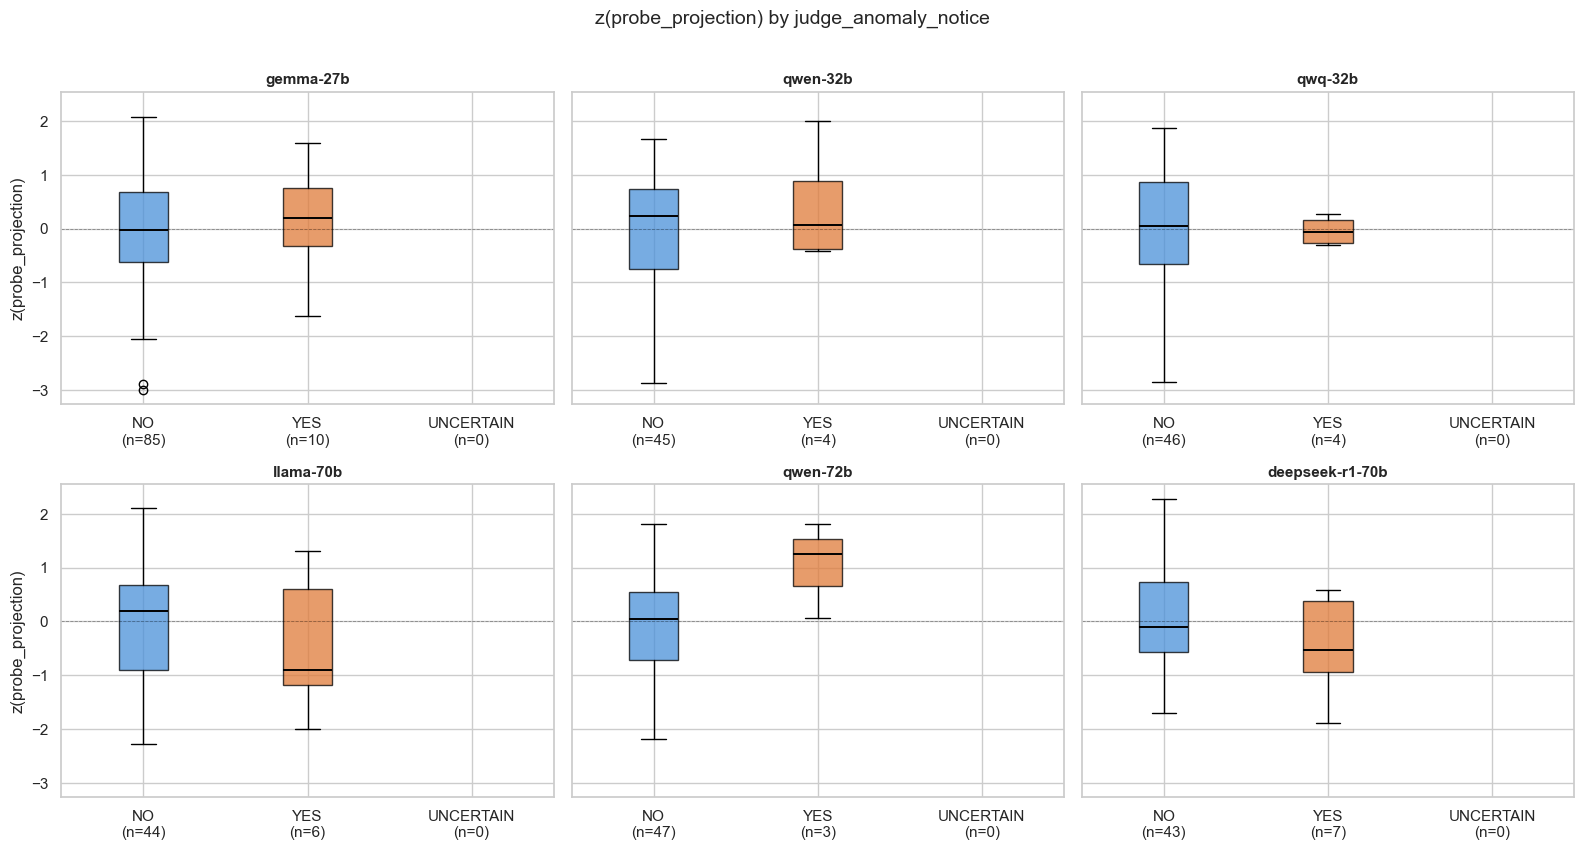

In [14]:
MODEL_COLORS = {
    'gemma-27b': '#4a90d9',
    'qwen-32b': '#e07b39',
    'qwq-32b': '#f0c040',
    'llama-70b': '#5dba6e',
    'qwen-72b': '#c0603a',
    'deepseek-r1-70b': '#9b59b6',
}

ANOMALY_PALETTE = {'NO': '#4a90d9', 'YES': '#e07b39', 'UNCERTAIN': '#aaaaaa'}
COMPLIANCE_PALETTE = {'COMPLY': '#5dba6e', 'REFUSE': '#e74c3c', 'UNCERTAIN': '#aaaaaa'}


Y_LABELS = {
    'z_projection': 'z(probe_projection)',
    'probe_projection': 'probe_projection',
}


def plot_projection_by_judge(judge_col, label_order, palette, y_col='z_projection', title_suffix=''):
    models = list(MODEL_DATASET.keys())
    ncols = 3
    nrows = (len(models) + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4.2 * nrows), sharey=True)
    axes = axes.flatten()

    for ax, model in zip(axes, models):
        df = dfs[model]
        groups = [df.loc[df[judge_col] == label, y_col].values for label in label_order]
        counts = [len(g) for g in groups]

        bp = ax.boxplot(
            groups,
            tick_labels=[f"{lab}\n(n={n})" for lab, n in zip(label_order, counts)],
            patch_artist=True,
            showfliers=True,
            medianprops={'color': 'black', 'linewidth': 1.4},
        )
        for patch, label in zip(bp['boxes'], label_order):
            patch.set_facecolor(palette[label])
            patch.set_alpha(0.75)

        ax.axhline(0, color='black', linewidth=0.6, linestyle='--', alpha=0.35)
        ax.set_title(model, fontsize=11, fontweight='bold')
        if ax.get_subplotspec().colspan.start == 0:
            ax.set_ylabel(Y_LABELS.get(y_col, y_col))

    for ax in axes[len(models):]:
        ax.set_visible(False)

    y_label = Y_LABELS.get(y_col, y_col.replace('_', ' '))
    fig.suptitle(
        f'{y_label} by {judge_col}{title_suffix}',
        fontsize=14,
        y=1.01,
    )
    fig.tight_layout()
    plt.show()


plot_projection_by_judge(
    'judge_anomaly_notice',
    JUDGE_COLS['judge_anomaly_notice'],
    ANOMALY_PALETTE,
)


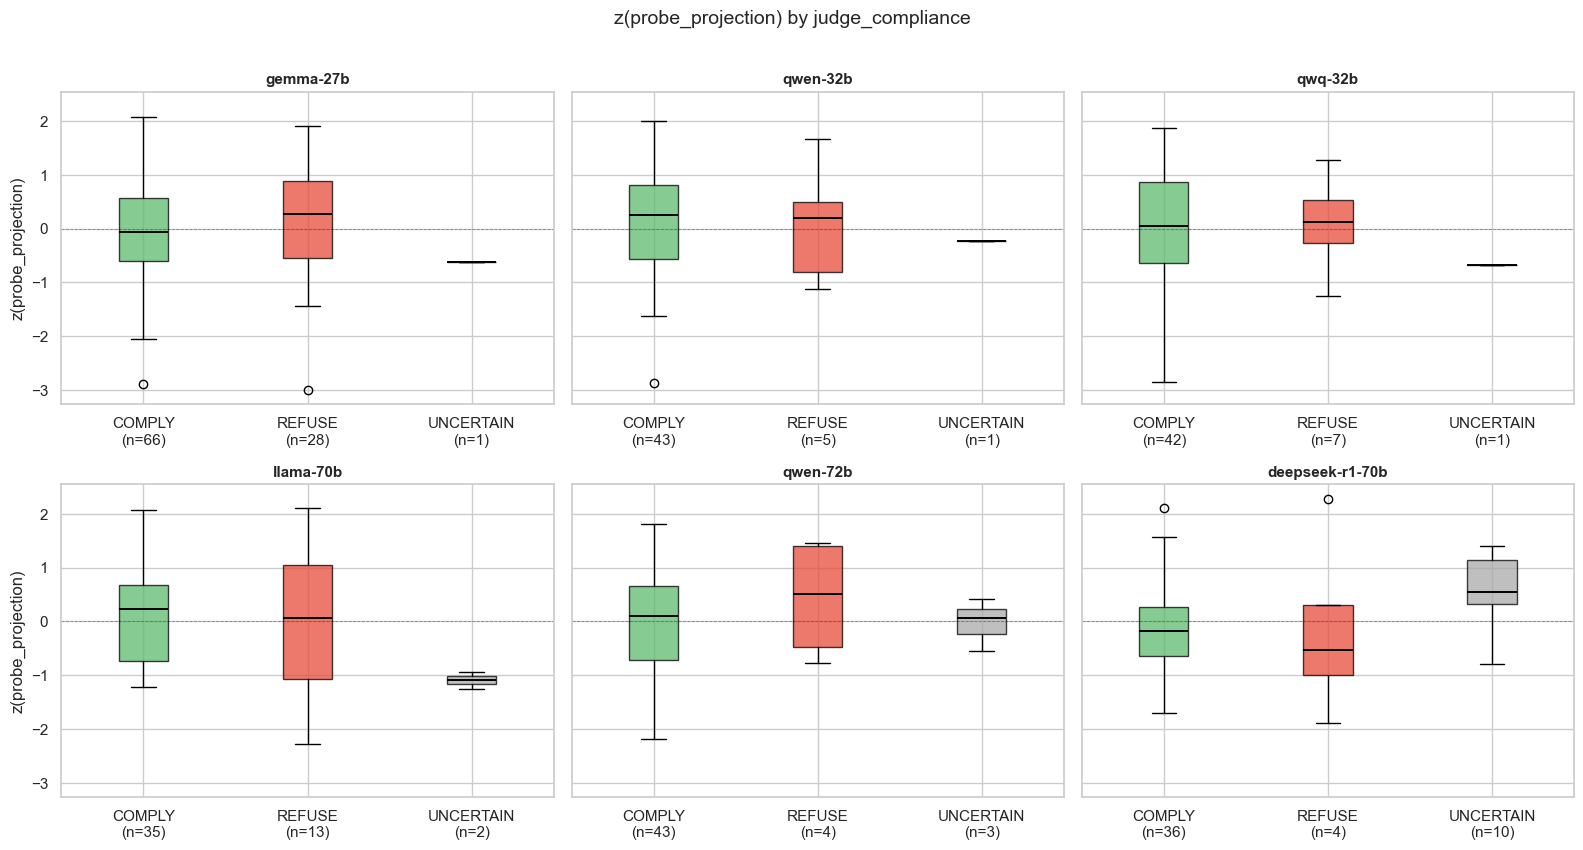

In [15]:
plot_projection_by_judge(
    'judge_compliance',
    JUDGE_COLS['judge_compliance'],
    COMPLIANCE_PALETTE
)


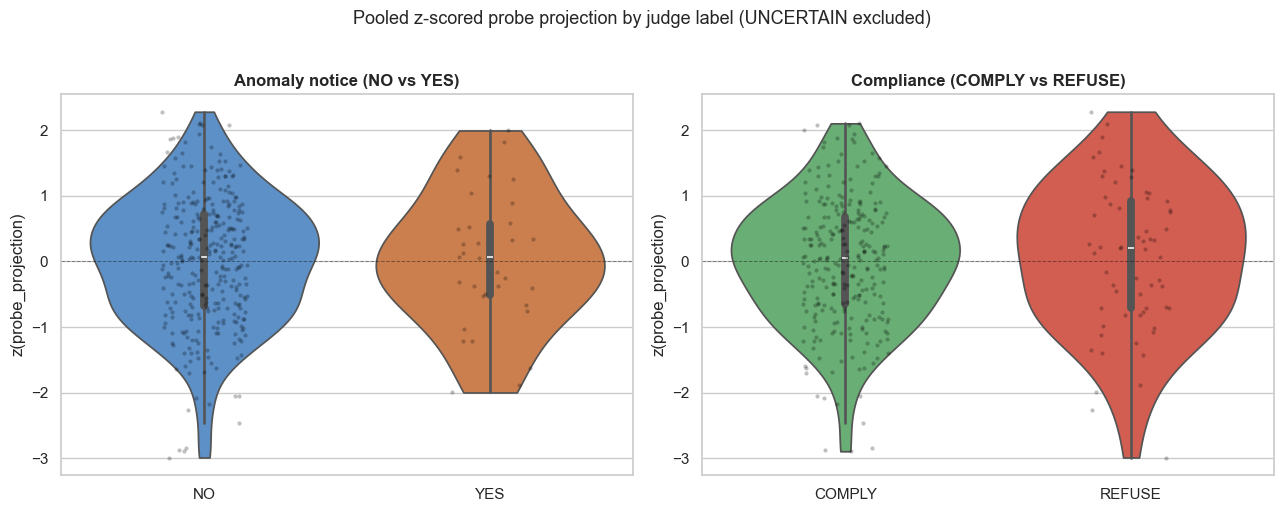

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

comparisons = [
    ('judge_anomaly_notice', ['NO', 'YES'], ANOMALY_PALETTE, 'Anomaly notice (NO vs YES)'),
    ('judge_compliance', ['COMPLY', 'REFUSE'], COMPLIANCE_PALETTE, 'Compliance (COMPLY vs REFUSE)'),
]

for ax, (judge_col, labels, palette, title) in zip(axes, comparisons):
    sub = all_df[all_df[judge_col].isin(labels)].copy()
    sns.violinplot(
        data=sub,
        x=judge_col,
        y='z_projection',
        order=labels,
        hue=judge_col,
        palette=palette,
        legend=False,
        inner='box',
        cut=0,
        ax=ax,
    )
    sns.stripplot(
        data=sub,
        x=judge_col,
        y='z_projection',
        order=labels,
        color='black',
        alpha=0.25,
        size=3,
        jitter=0.15,
        ax=ax,
    )
    ax.axhline(0, color='black', linewidth=0.7, linestyle='--', alpha=0.4)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('z(probe_projection)')

fig.suptitle('Pooled z-scored probe projection by judge label (UNCERTAIN excluded)', fontsize=13, y=1.02)
fig.tight_layout()
plt.show()

In [17]:
def summarize_judge_vs_projection(df, judge_col, positive_label, negative_label, value_col='z_projection'):
    pos = df.loc[df[judge_col] == positive_label, value_col]
    neg = df.loc[df[judge_col] == negative_label, value_col]
    if len(pos) < 2 or len(neg) < 2:
        return None

    # point-biserial correlation (binary label vs continuous projection)
    binary = df[judge_col].map({negative_label: 0, positive_label: 1})
    mask = binary.notna()
    r, r_p = stats.pearsonr(binary[mask], df.loc[mask, value_col])

    u_stat, u_p = stats.mannwhitneyu(pos, neg, alternative='two-sided')
    return {
        'n_pos': len(pos),
        'n_neg': len(neg),
        'mean_pos': pos.mean(),
        'mean_neg': neg.mean(),
        'delta_mean': pos.mean() - neg.mean(),
        'r': r,
        'r_p': r_p,
        'u_p': u_p,
    }


summary_rows = []
comparisons = [
    ('judge_anomaly_notice', 'YES', 'NO'),
    ('judge_compliance', 'REFUSE', 'COMPLY'),
]

for model in MODEL_DATASET:
    sub = all_df[all_df['model'] == model]
    for judge_col, pos, neg in comparisons:
        stats_row = summarize_judge_vs_projection(sub, judge_col, pos, neg)
        if stats_row is None:
            continue
        summary_rows.append({'model': model, 'comparison': f'{judge_col}: {pos} vs {neg}', **stats_row})

summary_df = pd.DataFrame(summary_rows).set_index(['model', 'comparison'])
summary_df[['n_pos', 'n_neg', 'mean_pos', 'mean_neg', 'delta_mean', 'r', 'r_p', 'u_p']].round(4)

n_pos  n_neg  mean_pos  \
model           comparison                                                   
gemma-27b       judge_anomaly_notice: YES vs NO        10     85    0.1924   
                judge_compliance: REFUSE vs COMPLY     28     66    0.1007   
qwen-32b        judge_anomaly_notice: YES vs NO         4     45    0.4317   
                judge_compliance: REFUSE vs COMPLY      5     43    0.0835   
qwq-32b         judge_anomaly_notice: YES vs NO         4     46   -0.0459   
                judge_compliance: REFUSE vs COMPLY      7     42    0.0984   
llama-70b       judge_anomaly_notice: YES vs NO         6     44   -0.4436   
                judge_compliance: REFUSE vs COMPLY     13     35   -0.1303   
qwen-72b        judge_anomaly_notice: YES vs NO         3     47    1.0487   
                judge_compliance: REFUSE vs COMPLY      4     43    0.4249   
deepseek-r1-70b judge_anomaly_notice: YES vs NO         7     43   -0.4170   
                judge_compliance: REFUSE vs COMPLY      4     36   -0.1661   

                                                    mean_neg  delta_mean  \
model           comparison                                                 
gemma-27b       judge_anomaly_notice: YES vs NO       0.0061      0.1863   
                judge_compliance: REFUSE vs COMPLY    0.0037      0.0970   
qwen-32b        judge_anomaly_notice: YES vs NO      -0.0125      0.4442   
                judge_compliance: REFUSE vs COMPLY    0.0226      0.0609   
qwq-32b         judge_anomaly_notice: YES vs NO       0.0040     -0.0499   
                judge_compliance: REFUSE vs COMPLY   -0.0004      0.0988   
llama-70b       judge_anomaly_notice: YES vs NO       0.0605     -0.5041   
                judge_compliance: REFUSE vs COMPLY    0.1108     -0.2411   
qwen-72b        judge_anomaly_notice: YES vs NO      -0.0669      1.1156   
                judge_compliance: REFUSE vs COMPLY   -0.0381      0.4630   
deepseek-r1-70b judge_anomaly_notice: YES vs NO       0.0679     -0.4849   
                judge_compliance: REFUSE vs COMPLY   -0.1321     -0.0340   

                                                         r     r_p     u_p  
model           comparison                                                  
gemma-27b       judge_anomaly_notice: YES vs NO     0.0587  0.5717  0.5687  
                judge_compliance: REFUSE vs COMPLY  0.0455  0.6635  0.4694  
qwen-32b        judge_anomaly_notice: YES vs NO     0.1234  0.3984  0.6344  
                judge_compliance: REFUSE vs COMPLY  0.0187  0.8997  0.9739  
qwq-32b         judge_anomaly_notice: YES vs NO    -0.0137  0.9249  0.8721  
                judge_compliance: REFUSE vs COMPLY  0.0347  0.8127  0.9203  
llama-70b       judge_anomaly_notice: YES vs NO    -0.1655  0.2508  0.4288  
                judge_compliance: REFUSE vs COMPLY -0.1089  0.4613  0.7191  
qwen-72b        judge_anomaly_notice: YES vs NO     0.2676  0.0602  0.0900  
                judge_compliance: REFUSE vs COMPLY  0.1271  0.3944  0.4806  
deepseek-r1-70b judge_anomaly_notice: YES vs NO    -0.1700  0.2380  0.3081  
                judge_compliance: REFUSE vs COMPLY -0.0102  0.9503  0.5568

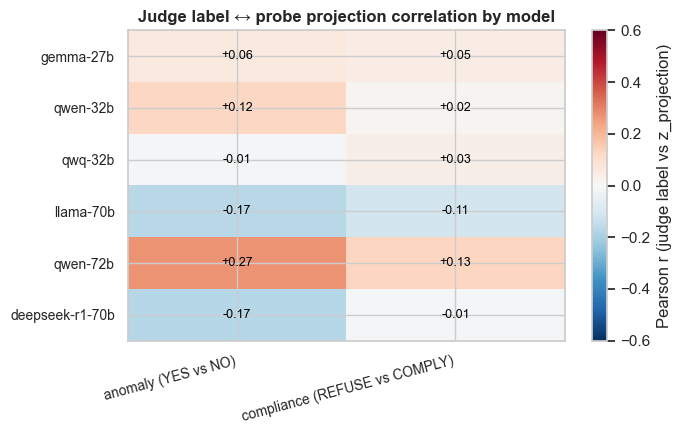

Mean |r| across models:
anomaly (YES vs NO)              0.133
compliance (REFUSE vs COMPLY)    0.058
dtype: float64


In [18]:
# Heatmap: point-biserial r between judge label and z_projection, per model

effect_rows = []
for model in MODEL_DATASET:
    sub = all_df[all_df['model'] == model]
    row = {'model': model}
    for judge_col, pos, neg in comparisons:
        binary = sub[judge_col].map({neg: 0, pos: 1})
        mask = binary.notna()
        if mask.sum() < 5 or binary[mask].nunique() < 2:
            row[judge_col] = np.nan
        else:
            row[judge_col], _ = stats.pearsonr(binary[mask], sub.loc[mask, 'z_projection'])
    effect_rows.append(row)

effect_df = pd.DataFrame(effect_rows).set_index('model')
effect_df.columns = ['anomaly (YES vs NO)', 'compliance (REFUSE vs COMPLY)']

fig, ax = plt.subplots(figsize=(7, 4.5))
im = ax.imshow(effect_df.values, aspect='auto', cmap='RdBu_r', vmin=-0.6, vmax=0.6)

ax.set_xticks(range(len(effect_df.columns)))
ax.set_xticklabels(effect_df.columns, rotation=15, ha='right', fontsize=10)
ax.set_yticks(range(len(effect_df)))
ax.set_yticklabels(effect_df.index, fontsize=10)

for i in range(len(effect_df)):
    for j in range(len(effect_df.columns)):
        val = effect_df.values[i, j]
        if np.isnan(val):
            txt = '—'
        else:
            txt = f'{val:+.2f}'
        ax.text(j, i, txt, ha='center', va='center', fontsize=9,
                color='white' if abs(val) > 0.35 else 'black')

plt.colorbar(im, ax=ax, label='Pearson r (judge label vs z_projection)')
ax.set_title('Judge label ↔ probe projection correlation by model', fontsize=12, fontweight='bold')
fig.tight_layout()
plt.show()

print('Mean |r| across models:')
print(effect_df.abs().mean().round(3))


=== judge_anomaly_notice vs probe_verdict (row %) ===


probe_verdict,eval-aware,not eval-aware
judge_anomaly_notice,,
NO,67.1,32.9
YES,55.9,44.1
UNCERTAIN,NaN,NaN


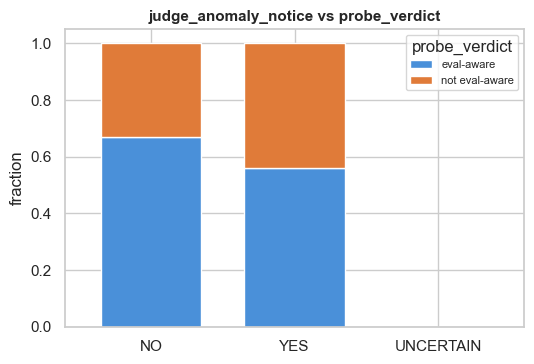


=== judge_compliance vs probe_verdict (row %) ===


probe_verdict,eval-aware,not eval-aware
judge_compliance,,
COMPLY,68.3,31.7
REFUSE,54.1,45.9
UNCERTAIN,72.2,27.8


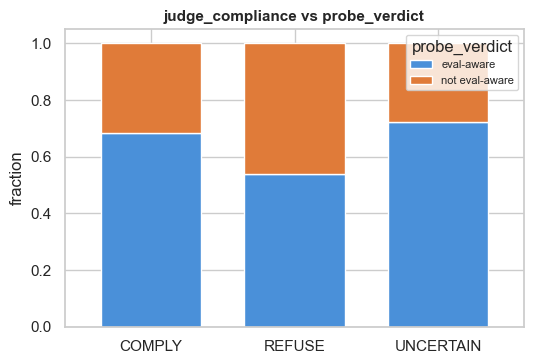

In [19]:
# Cross-tabulation: judge labels vs binary probe_verdict

verdict_label = {True: 'eval-aware', False: 'not eval-aware'}

for judge_col, order in JUDGE_COLS.items():
    ct = pd.crosstab(
        all_df[judge_col],
        all_df['probe_verdict'].map(verdict_label),
        normalize='index',
    ).reindex(order)
    ct_counts = pd.crosstab(all_df[judge_col], all_df['probe_verdict'].map(verdict_label)).reindex(order)

    print(f'\n=== {judge_col} vs probe_verdict (row %) ===')
    display((ct * 100).round(1))

    fig, ax = plt.subplots(figsize=(5.5, 3.8))
    ct.plot(kind='bar', stacked=True, ax=ax, color=['#4a90d9', '#e07b39'], width=0.7)
    ax.set_title(f'{judge_col} vs probe_verdict', fontsize=11, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('fraction')
    ax.legend(title='probe_verdict', fontsize=8)
    ax.set_xticklabels(order, rotation=0)
    fig.tight_layout()
    plt.show()